![display relevant image here](path/url/to/image)
- Banner/header image

# Title
- Relevant to Data and Business Context

## Overview
- BLUF (Bottom Line Up Front)
- One paragraph summary of final model performance and business implications
- Frame your 'story'

## Business Understanding

1. FinTech Innovations' loan approval process business context summary:

### 1. Business context

- FinTech Innovations wants to modernize a loan approval process that currently relies heavily on manual review by loan officers. Manual review is observed to be slower and produces inconsistent results across applicants. A custom data-driven model engineered for screening will standardize the first stage of assessment as well as provide the loan officers with a consistent & more reliable risk signal.

### Key stakeholders
| Stakeholder | Necessity |
|---|---|
| Loan officers | Consistent, explainable screening support |
| Risk/credit team | Control default exposure and monitor model performance |
| Management | Reduce financial losses while supporting profitable lending |
| Applicants | Timely and consistent decisions |
| Compliance/regulatory teams | Explainable decisions, monitoring and bias controls |
| Data/ML team | Reproducible, auditable and maintainable pipelines |




### Business implications of different types of model errors
- **False negative:** a creditworthy applicant is denied → approximately **8K** missed profit.
- **False positive:** a bad loan is approved and defaults → approximately **50K** loss.
A false positive costs **6.25 times** as much as a false negative, so the decision threshold should not automatically be set to 0.50.


### Classification versus regression
The notebook will utilize **classification** because the immediate business decision is binary: approve or don't approve. Classification directly supports confusion-matrix analysis and threshold optimization.
A regression/risk-score approach could also be useful in a production setting, but the supplied target `LoanApproved` is a binary decision. `RiskScore` is excluded from the predictive features because it is a derived risk variable and could potentially introduce leakage into an approval model.




2. Define your modeling goals and success criteria:

### Modeling goals
1. Build a preprocessing and modeling pipeline.
2. Compare multiple classification algorithms.
3. Use at least two statistical metrics and a business-cost metric.
4. Use cross-validation for tuning model hyperparameters.
5. Select a decision threshold based on training-only out-of-fold predictions.
6. Evaluate the untouched test set only after model and threshold selection.
7. Identify important features and potential limitations.



### Success criteria

The project will track:

- **ROC-AUC** — overall ranking/discrimination.
- **PR-AUC** — useful because approvals are the minority class.
- **Precision** — proportion of predicted approvals that are actually approved.
- **Recall** — proportion of actual approvals captured.
- **F1-score** — the balance between precision and recall.
- **Expected business error cost** — directly reflects the supplied 8K /50K costs.


A useful baseline is the **all-denied policy**, which would incur the 8000 opportunity cost for every actual approval in the test/training population. The ML model should aim to reduce this cost while maintaining acceptable statistical performance.


## Data Understanding
3. Conduct comprehensive exploratory data analysis:
- Describe basic data characteristics
- Examine distributions of all features and target variables
- Investigate relationships between features
- Create visualizations to help aid in EDA
- Document potential data quality issues and their implications

4. Develop feature understanding:
- Categorize features by type (numerical, categorical, ordinal)
- Identify features requiring special preprocessing
- Document missing value patterns and their potential meanings
- Note potential feature engineering opportunities


In [56]:
# Imports
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, mannwhitneyu

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate,
    RandomizedSearchCV, cross_val_predict
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, RocCurveDisplay, PrecisionRecallDisplay,
    make_scorer
)
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
COST_FN = 8_000
COST_FP = 50_000

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [60]:
# EDA Code Here - Create New Cells As Needed
df = pd.read_csv('financial_loan_data.csv')

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
display(df.head())


Rows: 20,000
Columns: 35


,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,Own,183,0.3544,1,2,0.3583,No,Home,0,29,9,"7,632.0000",1202,146111,19183,"3,329.0000",0.7250,11,126928,0.1997,0.2276,419.8060,0.1811,0,49.0000
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,Mortgage,496,0.0878,5,3,0.3303,No,Debt Consolidation,0,21,9,"4,627.0000",3460,53204,9595,"3,309.0833",0.9351,3,43609,0.2070,0.2011,794.0542,0.3899,0,52.0000
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,Rent,902,0.1374,2,0,0.2447,No,Education,0,20,22,886.0000,895,25176,128874,"3,393.6667",0.8722,6,5205,0.2176,0.2125,666.4067,0.4622,0,52.0000
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,Mortgage,755,0.2676,2,1,0.4362,No,Home,0,27,10,"1,675.0000",1217,104822,5370,"5,757.0000",0.8962,5,99452,0.3004,0.3009,"1,047.5070",0.3131,0,54.0000
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,Mortgage,274,0.3205,0,0,0.0789,No,Debt Consolidation,0,26,27,"1,555.0000",4981,244305,17286,"8,605.3333",0.9414,5,227019,0.1972,0.1760,330.1791,0.0702,1,36.0000


In [65]:
#Data types
print("Data types:")
display(df.dtypes.to_frame("dtype"))


Data types:


,dtype
Age,int64
AnnualIncome,str
CreditScore,int64
EmploymentStatus,str
EducationLevel,str
Experience,int64
LoanAmount,int64
LoanDuration,int64
MaritalStatus,str
NumberOfDependents,int64


In [66]:
#Duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())



Duplicate rows: 0


In [67]:
#Missing values
print("\nMissing values:")
missing_summary = (
    df.isna().sum()
      .to_frame("missing_count")
      .assign(missing_pct=lambda x: 100 * x["missing_count"] / len(df))
      .query("missing_count > 0")
      .sort_values("missing_count", ascending=False)
)
display(missing_summary)



Missing values:


,missing_count,missing_pct
MaritalStatus,1331,6.6550
EducationLevel,901,4.5050
SavingsAccountBalance,572,2.8600


In [68]:
#Unique values
print("\nUnique values:")
display(df.nunique().sort_values().to_frame("n_unique"))



Unique values:


,n_unique
PreviousLoanDefaults,2
BankruptcyHistory,2
LoanApproved,2
EmploymentStatus,3
HomeOwnershipStatus,4
MaritalStatus,4
EducationLevel,5
LoanPurpose,5
NumberOfDependents,6
NumberOfCreditInquiries,8


In [70]:
#Descriptive statistics
df.describe(include='all')

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
count,"20,000.0000",20000,"20,000.0000",20000,19099,"20,000.0000","20,000.0000","20,000.0000",18669,"20,000.0000",20000,"20,000.0000","20,000.0000","20,000.0000","20,000.0000","20,000.0000",20000,20000,"20,000.0000","20,000.0000","20,000.0000","19,428.0000","20,000.0000","20,000.0000","20,000.0000","20,000.0000","20,000.0000","20,000.0000","20,000.0000","20,000.0000","20,000.0000","20,000.0000","20,000.0000","20,000.0000","20,000.0000"
unique,NaN,17516,NaN,3,5,NaN,NaN,NaN,4,NaN,4,NaN,NaN,NaN,NaN,NaN,2,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,"$15,000.00",NaN,Employed,Bachelor,NaN,NaN,NaN,Married,NaN,Mortgage,NaN,NaN,NaN,NaN,NaN,No,Home,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,584,NaN,17036,5804,NaN,NaN,NaN,9370,NaN,7939,NaN,NaN,NaN,NaN,NaN,18952,5925,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,39.7526,NaN,571.6124,NaN,NaN,17.5227,"24,882.8678",54.0570,NaN,1.5173,NaN,454.2927,0.2864,3.0234,0.9930,0.2857,NaN,NaN,0.1001,23.9936,14.9573,"4,949.1484","1,782.5551","96,964.3955","36,252.4128","4,891.7155",0.7999,5.0027,"72,294.3188",0.2391,0.2391,911.6071,0.4022,0.2390,50.7668
std,11.6227,NaN,50.9974,NaN,NaN,11.3168,"13,427.4212",24.6649,NaN,1.3863,NaN,240.5076,0.1598,1.7362,0.9870,0.1602,NaN,NaN,0.3001,4.9454,8.3716,"6,628.4050","2,245.3788","120,799.9392","47,251.5109","3,296.7716",0.1207,2.2368,"117,920.0214",0.0355,0.0422,674.5835,0.3389,0.4265,7.7783
min,18.0000,NaN,343.0000,NaN,NaN,0.0000,"3,674.0000",12.0000,NaN,0.0000,NaN,50.0000,0.0010,0.0000,0.0000,0.0017,NaN,NaN,0.0000,8.0000,1.0000,73.0000,24.0000,"2,098.0000",372.0000,"1,250.0000",0.2592,0.0000,"1,000.0000",0.1301,0.1133,97.0302,0.0160,0.0000,28.8000
25%,32.0000,NaN,540.0000,NaN,NaN,9.0000,"15,575.0000",36.0000,NaN,0.0000,NaN,286.0000,0.1608,2.0000,0.0000,0.1610,NaN,NaN,0.0000,21.0000,8.0000,"1,542.0000",551.0000,"31,180.2500","11,196.7500","2,629.5833",0.7274,3.0000,"8,734.7500",0.2139,0.2091,493.7637,0.1797,0.0000,46.0000
50%,40.0000,NaN,578.0000,NaN,NaN,17.0000,"21,914.5000",48.0000,NaN,1.0000,NaN,402.0000,0.2667,3.0000,1.0000,0.2645,NaN,NaN,0.0000,24.0000,15.0000,"2,988.5000","1,116.0000","60,699.0000","22,203.0000","4,034.7500",0.8210,5.0000,"32,855.5000",0.2362,0.2354,728.5115,0.3027,0.0000,52.0000
75%,48.0000,NaN,609.0000,NaN,NaN,25.0000,"30,835.0000",72.0000,NaN,2.0000,NaN,564.0000,0.3906,4.0000,2.0000,0.3903,NaN,NaN,0.0000,27.0000,22.0000,"5,869.2500","2,126.0000","117,405.2500","43,146.5000","6,163.0000",0.8923,6.0000,"88,825.5000",0.2615,0.2655,"1,112.7708",0.5092,0.0000,56.0000


,count,percentage
LoanApproved,,
0,15220,76.1000
1,4780,23.9000


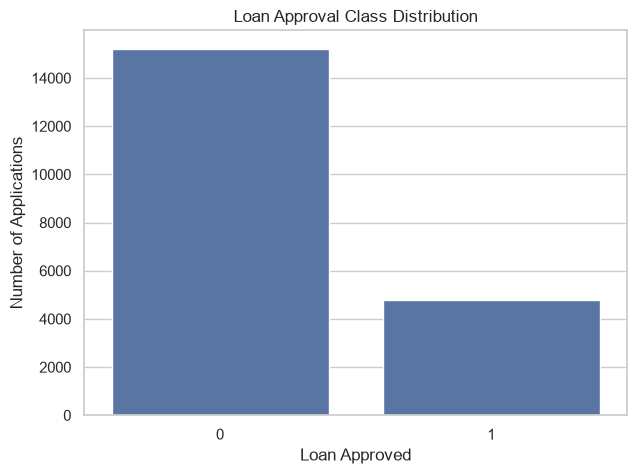

Approval rate: 23.90%
Majority-class baseline accuracy: 76.10%
PR-AUC no-skill prevalence baseline: 0.2390


In [73]:
# Target distribution (adjust target column name)

TARGET = "LoanApproved"

target_counts = df[TARGET].value_counts().sort_index()
target_pct = df[TARGET].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_pct.round(2)
})
display(target_summary)

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x=TARGET)
plt.title("Loan Approval Class Distribution")
plt.xlabel("Loan Approved")
plt.ylabel("Number of Applications")
plt.show()

approval_rate = df[TARGET].mean()
print(f"Approval rate: {approval_rate:.2%}")
print(f"Majority-class baseline accuracy: {max(target_pct) / 100:.2%}")
print(f"PR-AUC no-skill prevalence baseline: {approval_rate:.4f}")

- The target is **LoanApproved**. 
- REASON: An imbalanced target can make accuracy misleading, the notebook reports the class counts and approval rate before model training.

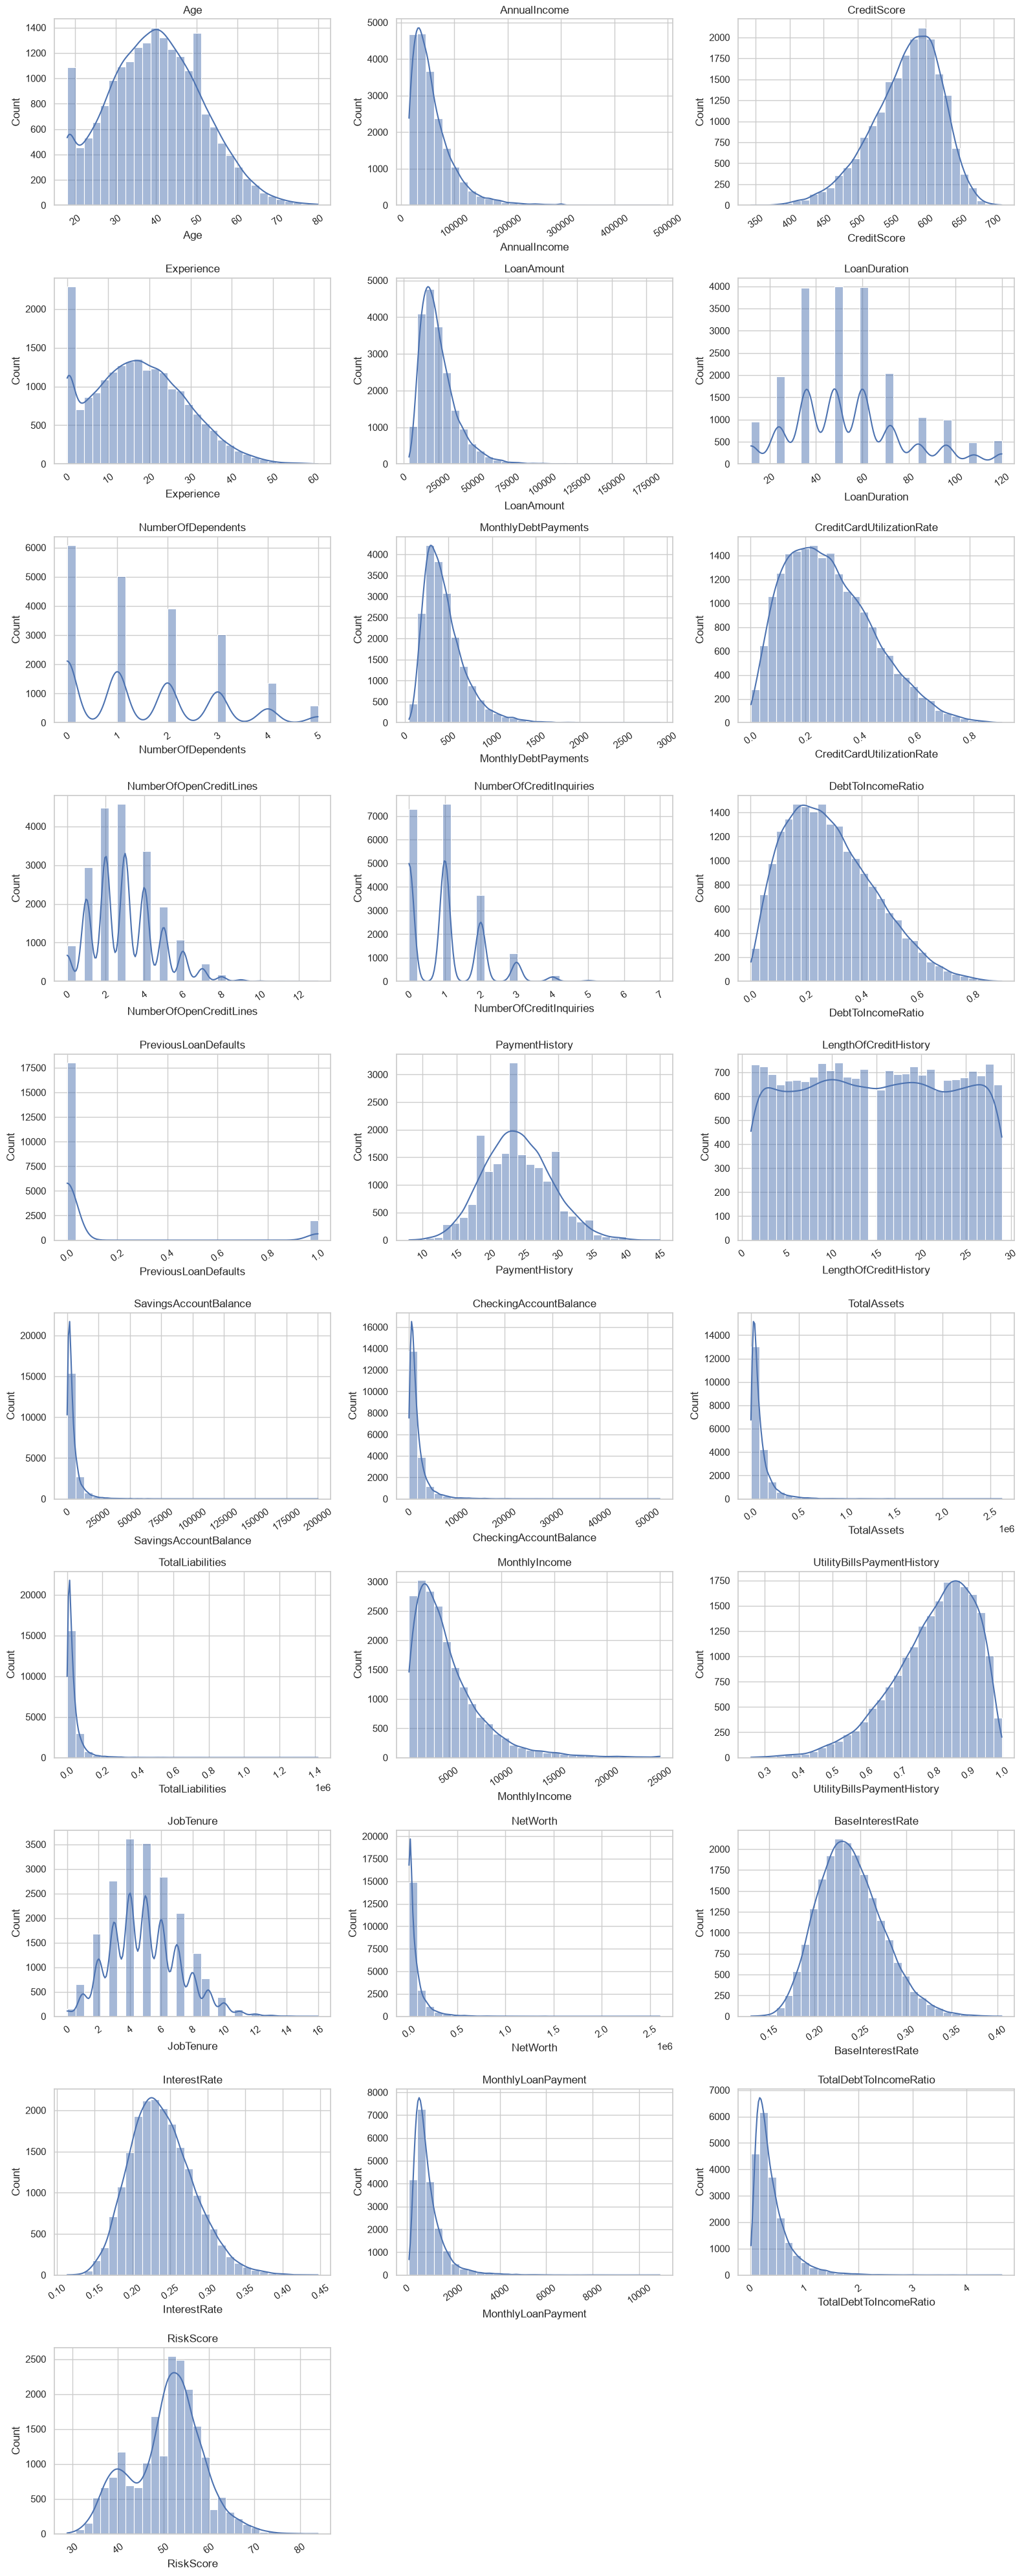

In [80]:
# Numeric distributions - There is conversion of AnnualIncome temporarily for EDA only

eda_df = df.copy()
eda_df["AnnualIncome"] = (
    eda_df["AnnualIncome"].astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .replace("nan", np.nan)
    .astype(float)
)

numeric_cols = eda_df.select_dtypes(include=np.number).columns.tolist()
numeric_features_eda = [col for col in numeric_cols if col != TARGET]

numcols = 3
numrows = int(np.ceil(len(numeric_features_eda) / numcols))
fig, axes = plt.subplots(numrows, numcols, figsize=(16, 4 * numrows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, numeric_features_eda):
    sns.histplot(eda_df[col], bins=30, kde=True, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=35)

for ax in axes[len(numeric_features_eda):]:
    ax.remove()

plt.tight_layout()
plt.show()

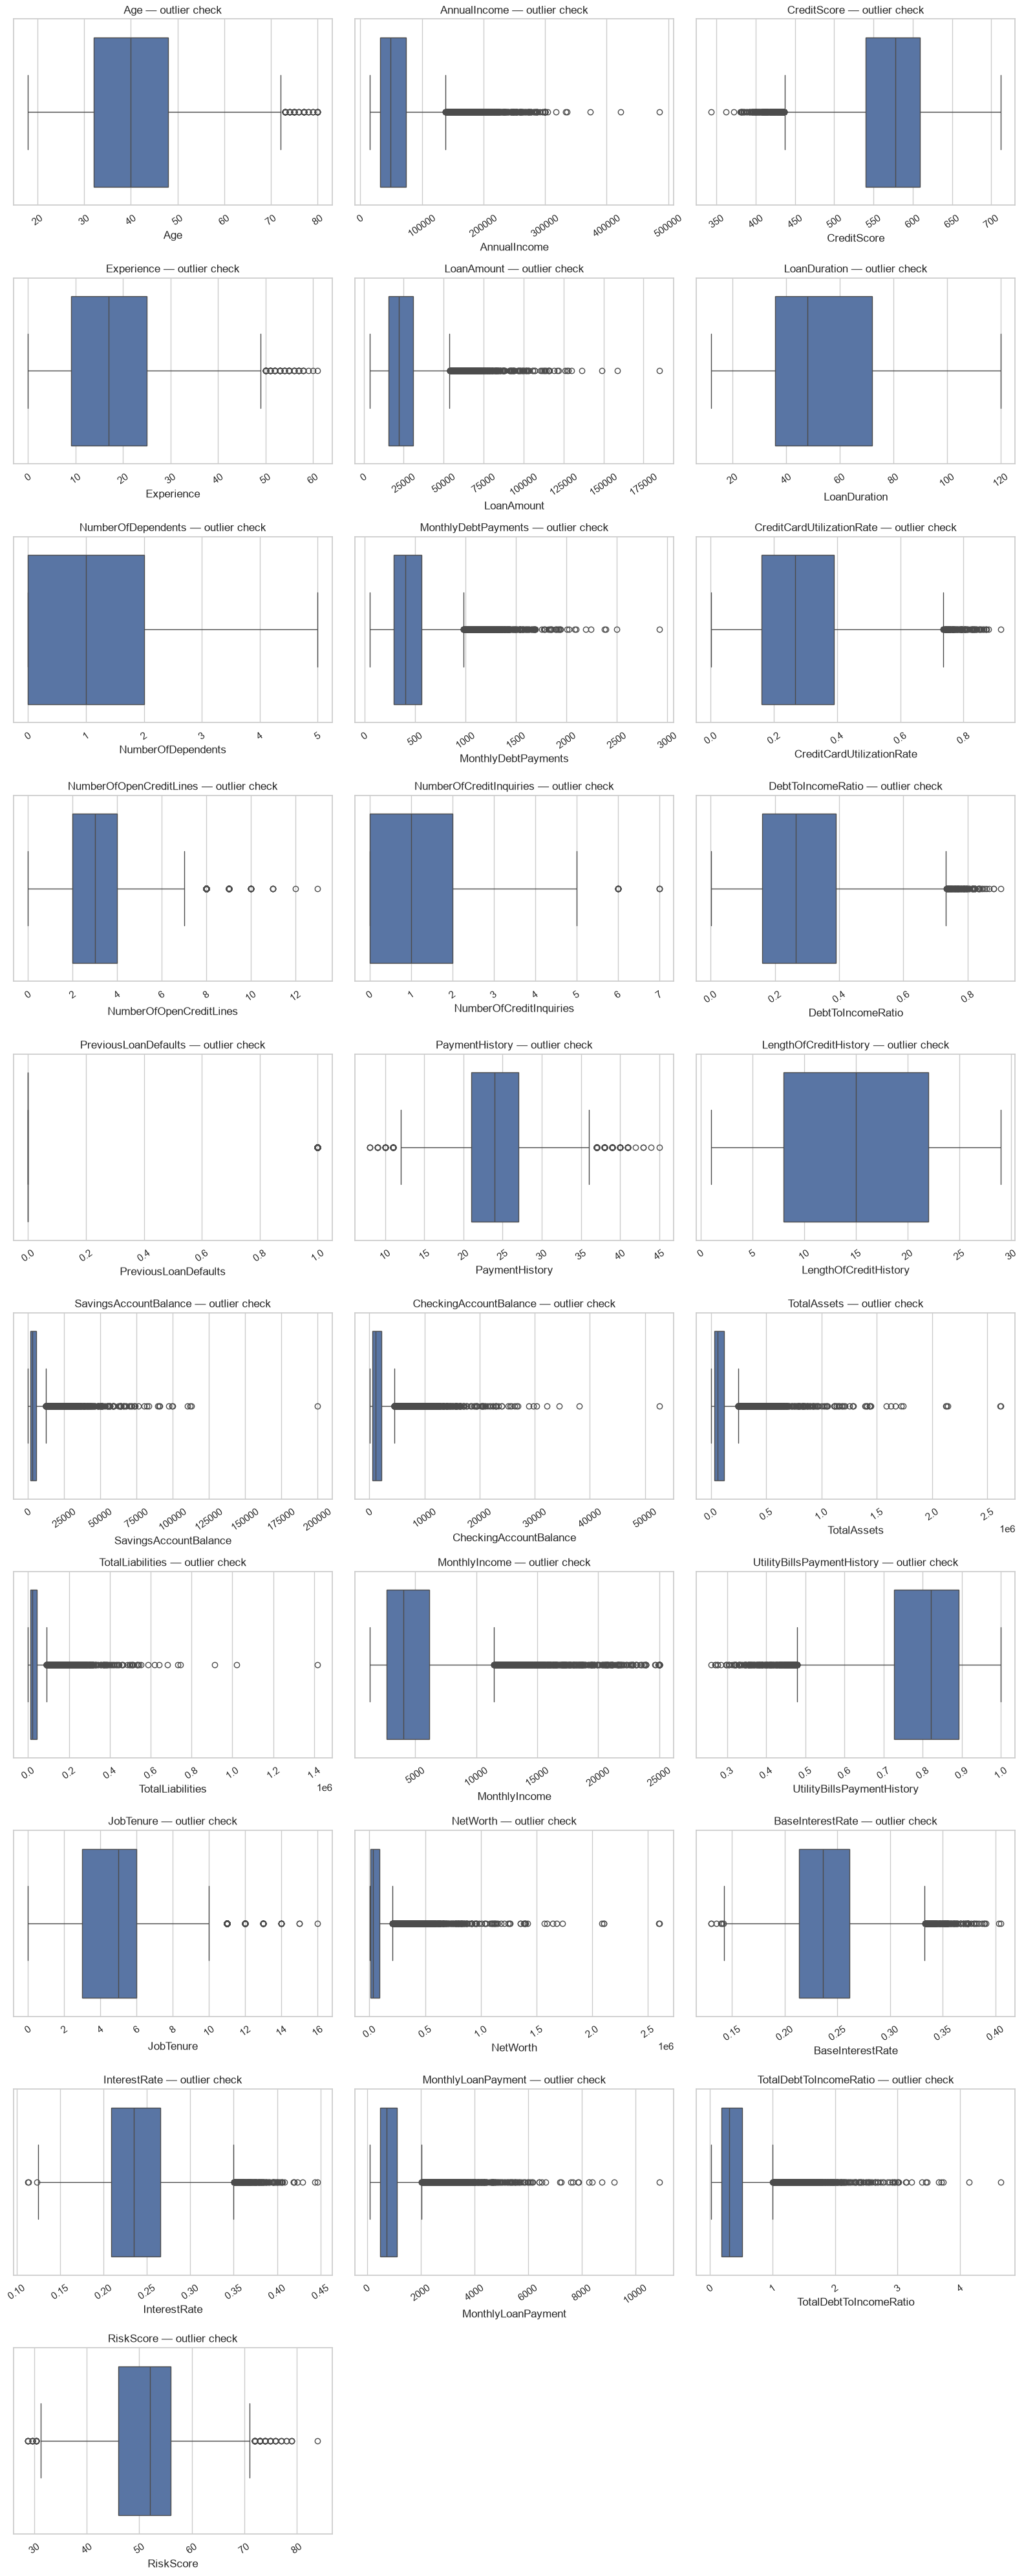

In [81]:
# Boxplots - Aid in identifying potential outliers among numerical features

numcols = 3
numrows = int(np.ceil(len(numeric_features_eda) / numcols))
fig, axes = plt.subplots(numrows, numcols, figsize=(16, 4 * numrows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, numeric_features_eda):
    sns.boxplot(x=eda_df[col], ax=ax)
    ax.set_title(f"{col} — outlier check")
    ax.tick_params(axis="x", rotation=35)

for ax in axes[len(numeric_features_eda):]:
    ax.remove()

plt.tight_layout()
plt.show()

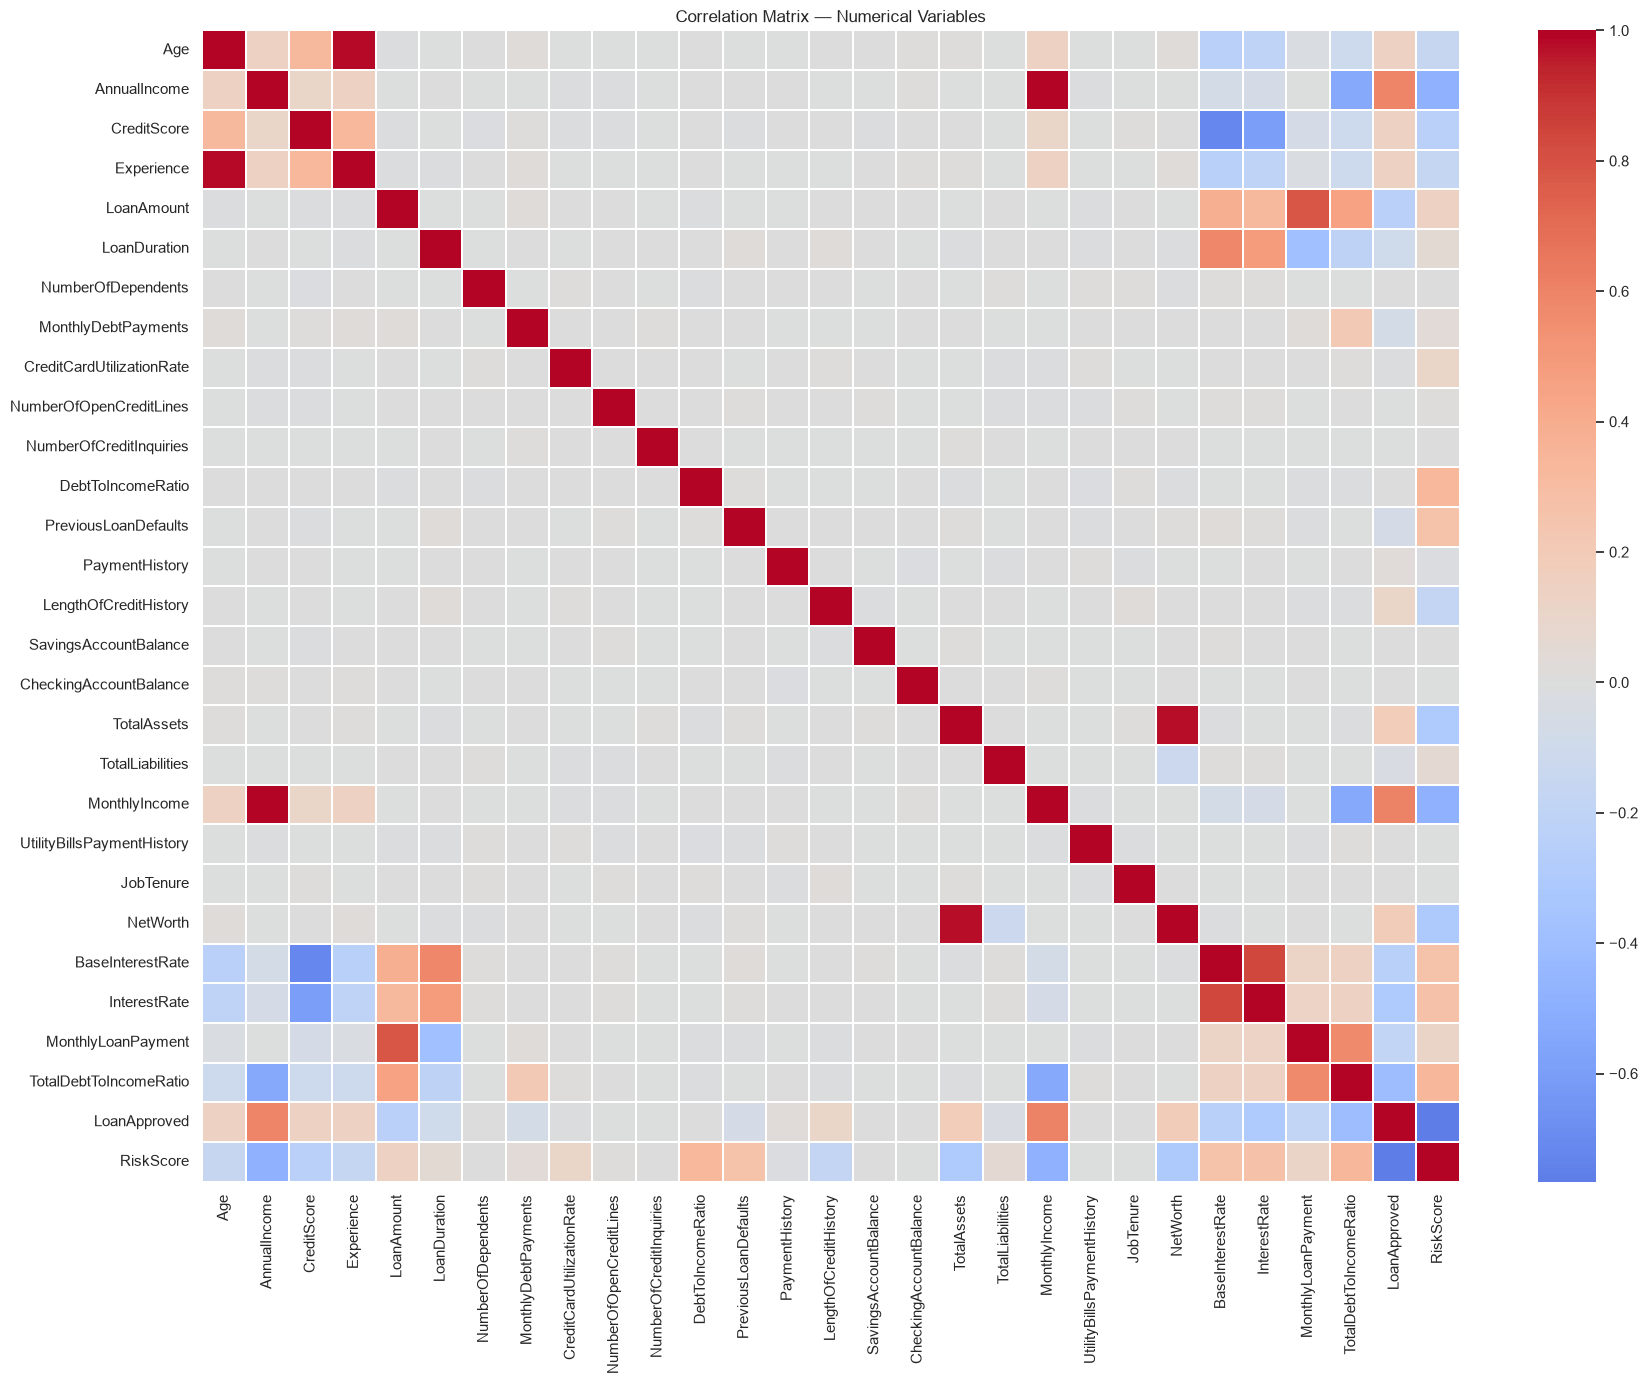

,absolute_correlation_with_target
RiskScore,0.7661
MonthlyIncome,0.6041
AnnualIncome,0.5979
TotalDebtToIncomeRatio,0.4104
InterestRate,0.3016
BaseInterestRate,0.2473
LoanAmount,0.2395
NetWorth,0.1879
MonthlyLoanPayment,0.1843
TotalAssets,0.1840


In [82]:
# Correlation matrix for numerical features
plt.figure(figsize=(18, 14))
corr = eda_df[numeric_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.2)
plt.title("Correlation Matrix — Numerical Variables")
plt.tight_layout()
plt.show()

target_corr = (
    corr[TARGET]
    .drop(TARGET)
    .abs()
    .sort_values(ascending=False)
    .to_frame("absolute_correlation_with_target")
)
display(target_corr.head(15))

Correlation has been used as a screening tool rather than proof of causation. The heatmap aids in identification of relationships between financial variables and potential multicollinearity.

### Bivariate analysis

The following plots examine relationships between important financial/credit variables and the approval target.

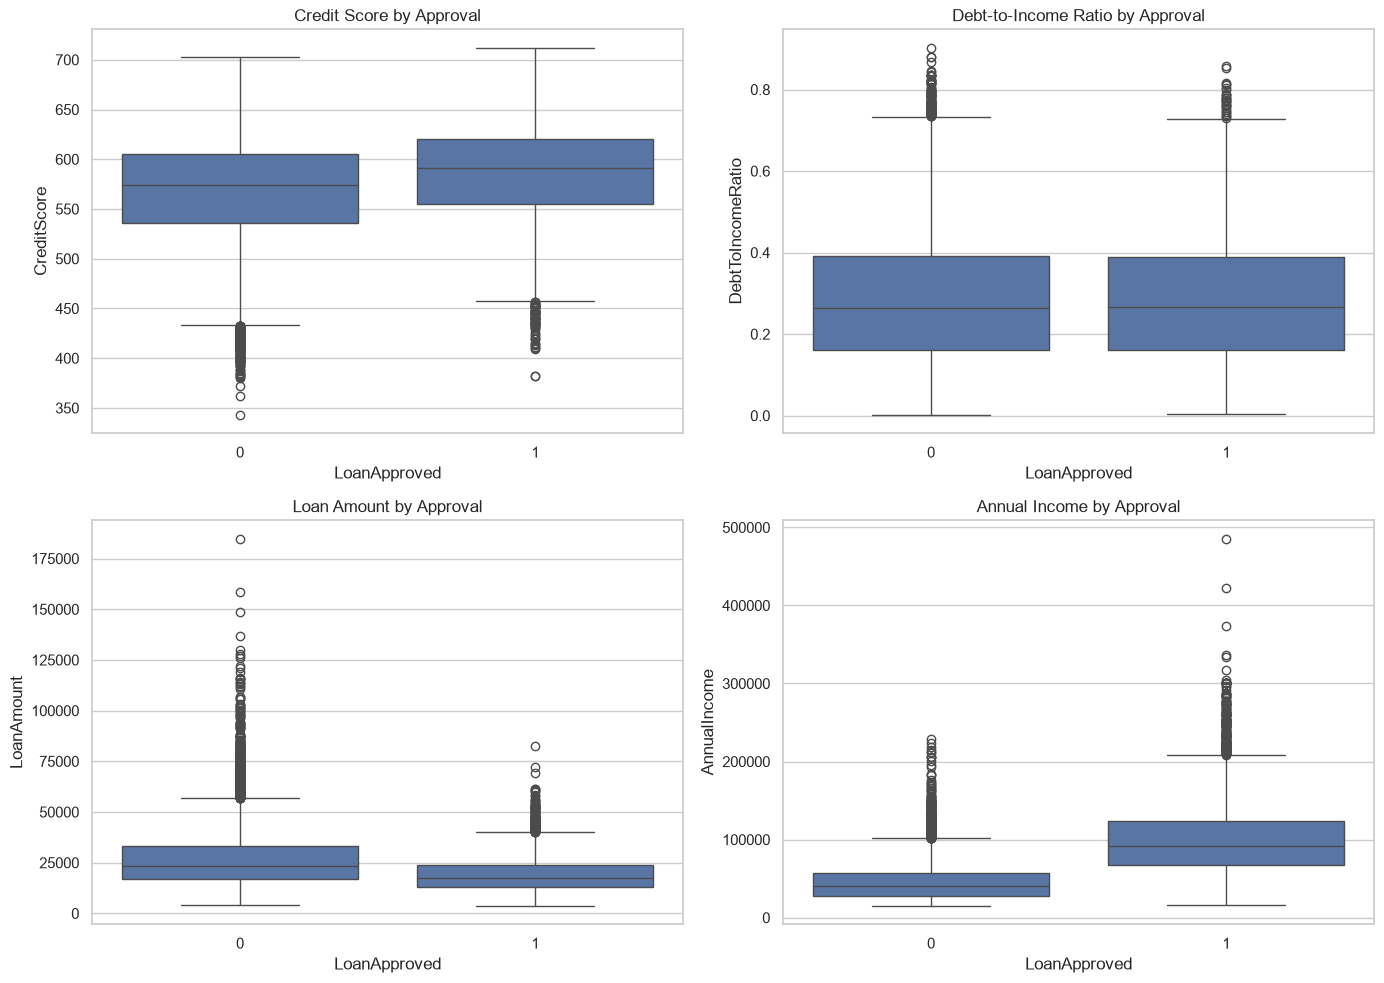

In [83]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=eda_df, x=TARGET, y="CreditScore", ax=axes[0, 0])
axes[0, 0].set_title("Credit Score by Approval")

sns.boxplot(data=eda_df, x=TARGET, y="DebtToIncomeRatio", ax=axes[0, 1])
axes[0, 1].set_title("Debt-to-Income Ratio by Approval")

sns.boxplot(data=eda_df, x=TARGET, y="LoanAmount", ax=axes[1, 0])
axes[1, 0].set_title("Loan Amount by Approval")

sns.boxplot(data=eda_df, x=TARGET, y="AnnualIncome", ax=axes[1, 1])
axes[1, 1].set_title("Annual Income by Approval")

plt.tight_layout()
plt.show()

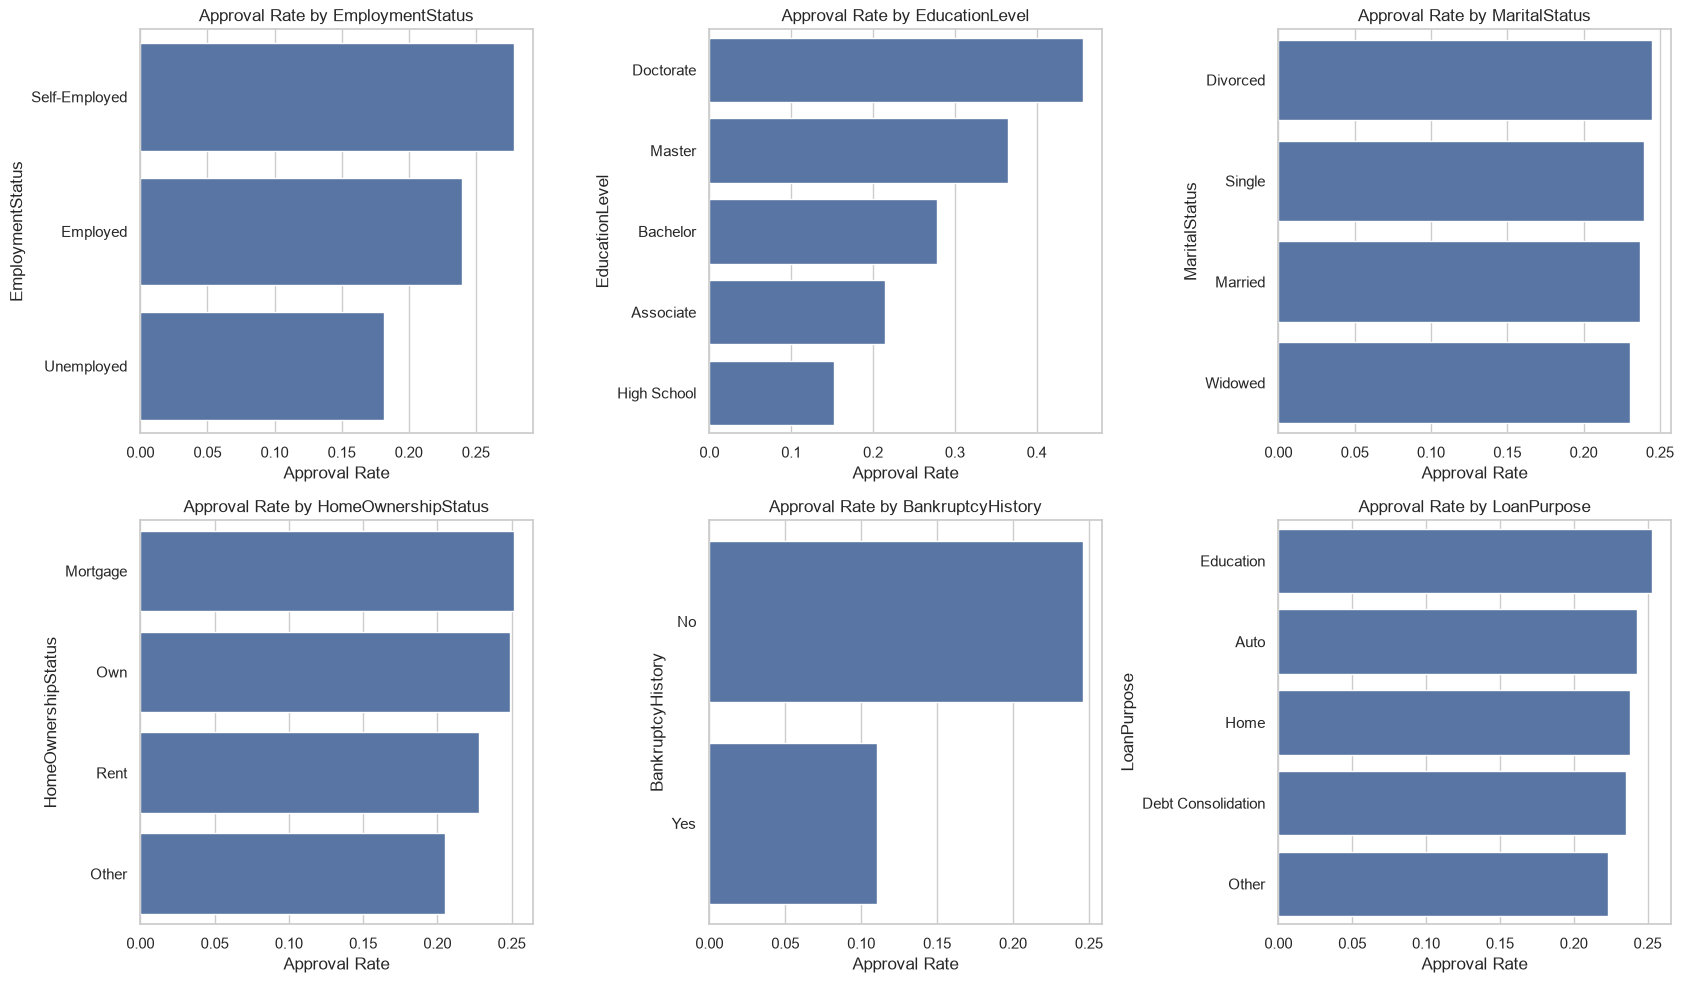

In [84]:
# Categorical relationships with approval
categorical_eda = [
    "EmploymentStatus", "EducationLevel", "MaritalStatus",
    "HomeOwnershipStatus", "BankruptcyHistory", "LoanPurpose"
]

fig, axes = plt.subplots(2, 3, figsize=(17, 10))

for ax, col in zip(axes.flat, categorical_eda):
    approval_rates = eda_df.groupby(col, dropna=False)[TARGET].mean().sort_values(ascending=False)
    sns.barplot(x=approval_rates.values, y=approval_rates.index.astype(str), ax=ax)
    ax.set_title(f"Approval Rate by {col}")
    ax.set_xlabel("Approval Rate")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

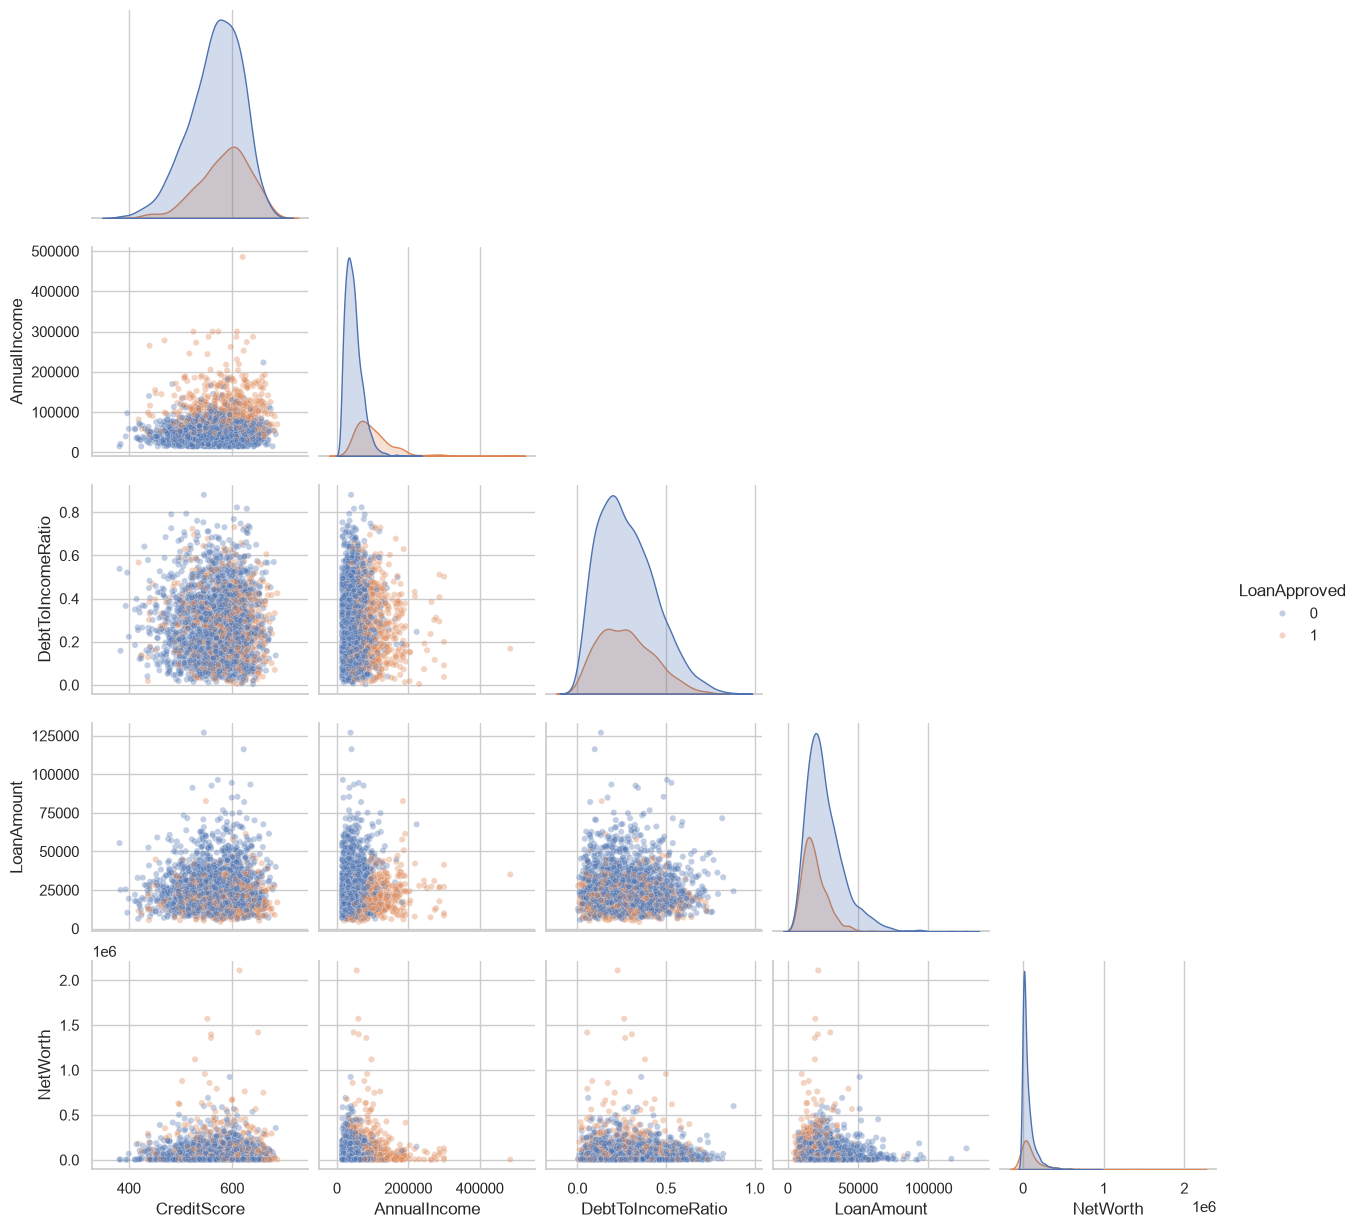

In [85]:
# Pairplot using a representative sample to keep rendering manageable
pair_cols = [
    "CreditScore", "AnnualIncome", "DebtToIncomeRatio",
    "LoanAmount", "NetWorth", TARGET
]
pair_sample = eda_df[pair_cols].sample(
    n=min(2500, len(eda_df)), random_state=RANDOM_STATE
)

sns.pairplot(
    pair_sample,
    vars=pair_cols[:-1],
    hue=TARGET,
    corner=True,
    plot_kws={"alpha": 0.35, "s": 20}
)
plt.show()

### Statistical relationship checks

These tests are descriptive diagnostics, not causal claims.

- For categorical variables, a chi-square test checks whether category membership and approval status are statistically associated.
- For numerical variables, a Mann–Whitney U test checks whether the distributions differ between approved and non-approved groups.

Because the dataset is large, statistical significance should be interpreted alongside effect size and business relevance.

In [86]:
# Chi-square tests for categorical features
chi_results = []

for col in categorical_eda:
    table = pd.crosstab(df[col].fillna("Missing"), df[TARGET])
    chi2, p, dof, expected = chi2_contingency(table)
    chi_results.append({
        "Feature": col,
        "Chi2": chi2,
        "p_value": p,
        "Significant_at_0.05": p < 0.05
    })

display(pd.DataFrame(chi_results).sort_values("p_value"))

,Feature,Chi2,p_value,Significant_at_0.05
1,EducationLevel,"1,068.9276",0.0000,True
4,BankruptcyHistory,99.3709,0.0000,True
0,EmploymentStatus,38.5065,0.0000,True
3,HomeOwnershipStatus,26.3288,0.0000,True
5,LoanPurpose,6.6957,0.1529,False
2,MaritalStatus,1.3740,0.8487,False


In [87]:
# Mann-Whitney U tests for numerical features
mw_results = []

for col in numeric_features_eda:
    approved = eda_df.loc[eda_df[TARGET] == 1, col].dropna()
    denied = eda_df.loc[eda_df[TARGET] == 0, col].dropna()

    stat, p = mannwhitneyu(approved, denied, alternative="two-sided")

    mw_results.append({
        "Feature": col,
        "U_statistic": stat,
        "p_value": p,
        "Significant_at_0.05": p < 0.05
    })

display(pd.DataFrame(mw_results).sort_values("p_value").head(20))

,Feature,U_statistic,p_value,Significant_at_0.05
1,AnnualIncome,"64,291,967.0000",0.0000,True
26,TotalDebtToIncomeRatio,"6,810,709.0000",0.0000,True
27,RiskScore,"920,927.0000",0.0000,True
19,MonthlyIncome,"64,386,016.0000",0.0000,True
24,InterestRate,"21,210,573.5000",0.0000,True
4,LoanAmount,"23,564,656.5000",0.0000,True
23,BaseInterestRate,"24,108,410.5000",0.0000,True
25,MonthlyLoanPayment,"25,434,898.0000",0.0000,True
3,Experience,"43,492,959.5000",0.0000,True
0,Age,"43,435,118.0000",0.0000,True


## Data Preparation
5. Design your preprocessing strategy:
- Create separate preprocessing flows for different feature types
- Must utilize ColumnTransformer and Pipeline
- Consider using FeatureUnion as well
- Handle missing values appropriately for each feature
- Handle Categorical and Ordinal data appropriately
- Scale numeric values if model requires it (linear model)
- Document your reasoning for each preprocessing decision



In [88]:
# Data Prep Code Here - Create New Cells As Needed

# Define raw X and y
X = df.drop(columns=[TARGET, "RiskScore"]).copy()
y = df[TARGET].astype(int)

class LoanDataCleaner(BaseEstimator, TransformerMixin):
    """Clean known raw-format fields while preserving a DataFrame."""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        X["AnnualIncome"] = (
            X["AnnualIncome"].astype(str)
            .str.replace("$", "", regex=False)
            .str.replace(",", "", regex=False)
            .replace({"nan": np.nan, "None": np.nan, "": np.nan})
            .astype(float)
        )

        return X

cleaner = LoanDataCleaner()

# Feature groups are based on the raw dataset after identifying AnnualIncome as numeric.
numeric_features = [
    "Age", "AnnualIncome", "CreditScore", "Experience", "LoanAmount",
    "LoanDuration", "NumberOfDependents", "MonthlyDebtPayments",
    "CreditCardUtilizationRate", "NumberOfOpenCreditLines",
    "NumberOfCreditInquiries", "DebtToIncomeRatio",
    "PreviousLoanDefaults", "PaymentHistory", "LengthOfCreditHistory",
    "SavingsAccountBalance", "CheckingAccountBalance", "TotalAssets",
    "TotalLiabilities", "MonthlyIncome", "UtilityBillsPaymentHistory",
    "JobTenure", "NetWorth", "BaseInterestRate", "InterestRate",
    "MonthlyLoanPayment", "TotalDebtToIncomeRatio"
]

categorical_features = [
    "EmploymentStatus", "MaritalStatus", "HomeOwnershipStatus",
    "BankruptcyHistory", "LoanPurpose"
]

ordinal_features = ["EducationLevel"]
ordinal_categories = [["High School", "Associate", "Bachelor", "Master", "Doctorate"]]

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Ordinal features:", len(ordinal_features))


Numeric features: 27
Categorical features: 5
Ordinal features: 1


In [89]:
# Preprocessing pipelines
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

ordinal_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(
        categories=ordinal_categories,
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
    ("ord", ordinal_transformer, ordinal_features)
], remainder="drop")

In [90]:
# Train/test split — test set remains untouched until final evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Training approval rate:", y_train.mean())
print("Test approval rate:", y_test.mean())

Training rows: 16000
Test rows: 4000
Training approval rate: 0.239
Test approval rate: 0.239


A complete scikit-learn pipeline is used so that every transformation is learned only from the training folds.

1. A custom transformer cleans the currency-formatted **AnnualIncome**.
2. Numerical features: median imputation → standardization.
3. Nominal categorical features: most-frequent imputation → one-hot encoding.
4. Ordinal **EducationLevel**: most-frequent imputation → ordinal encoding.
5. **RiskScore** is excluded because it is a derived risk variable.
6. **ColumnTransformer** combines the feature-specific flows.
7. The model is appended after preprocessing in one complete **Pipeline**.

This structure prevents preprocessing leakage during cross-validation.

## Modeling
6. Implement your modeling approach:
- Choose appropriate model algorithms based on your problem definition
- Set up validation strategy with chosen metrics
- Use a train test split and cross validation
- Create complete pipeline including any preprocessing and model
- Document your reasoning for each modeling decision

7. Optimize your model:
- Define parameter grid based on your understanding of the algorithms
- Implement GridSearchCV and/or RandomizedSearchCV with chosen metrics
- Consider tuning preprocessing steps
- Track and document the impact of different parameter combinations
- Consider the trade-offs between different model configurations

NOTE: Be mindful of time considerations - showcase “how to tune” 


In [91]:
#  Modeling Code Here - Create New Cells as Needed
# Business metrics
def business_error_cost(y_true, y_pred, cost_fn=COST_FN, cost_fp=COST_FP):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return cost_fn * fn + cost_fp * fp

def business_profit(y_true, y_pred, profit_good=COST_FN, loss_bad=COST_FP):
    """
    Simplified contribution relative to an approve/deny decision:
    +$8,000 for each correctly approved good loan (TP)
    -$50,000 for each incorrectly approved bad loan (FP)
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return profit_good * tp - loss_bad * fp

def cost_scorer(estimator, X_val, y_val):
    return -business_error_cost(y_val, estimator.predict(X_val))

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "accuracy": "accuracy",
    "business_cost": make_scorer(
        business_error_cost,
        greater_is_better=False
    )
}

In [93]:
# Baseline policies
all_denied_cost = business_error_cost(y_train, np.zeros(len(y_train), dtype=int))
all_approved_cost = business_error_cost(y_train, np.ones(len(y_train), dtype=int))

print(f"All-denied training cost:   {all_denied_cost:,.0f}")
print(f"All-approved training cost: {all_approved_cost:,.0f}")

baseline_targets = pd.DataFrame({
    "Metric": ["ROC-AUC", "PR-AUC", "Expected Cost"],
    "Baseline / Target": [
        "0.50 no-skill; target > 0.70",
        f"{approval_rate:.3f} prevalence; target > baseline",
        f"Below all-denied baseline ({all_denied_cost:,.0f} on training set)"
    ]
})
display(baseline_targets)

All-denied training cost:   30,592,000
All-approved training cost: 608,800,000


,Metric,Baseline / Target
0,ROC-AUC,0.50 no-skill; target > 0.70
1,PR-AUC,0.239 prevalence; target > baseline
2,Expected Cost,"Below all-denied baseline (30,592,000 on train..."


In [45]:

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [94]:
# Model comparison
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1500, class_weight="balanced", solver="liblinear",
        random_state=RANDOM_STATE
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8, min_samples_leaf=20, class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=250, max_depth=18, min_samples_leaf=3,
        class_weight="balanced_subsample", n_jobs=-1,
        random_state=RANDOM_STATE
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=250, max_depth=20, min_samples_leaf=2,
        class_weight="balanced", n_jobs=-1,
        random_state=RANDOM_STATE
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150, learning_rate=0.05, max_depth=3,
        min_samples_leaf=5, random_state=RANDOM_STATE
    )
}

comparison_rows = []

for name, model in models.items():
    pipe = Pipeline([
        ("cleaner", cleaner),
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    comparison_rows.append({
        "Model": name,
        "ROC-AUC": scores["test_roc_auc"].mean(),
        "PR-AUC": scores["test_pr_auc"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "Accuracy": scores["test_accuracy"].mean(),
        "Expected Cost": -scores["test_business_cost"].mean()
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values("Expected Cost")
display(comparison_df)

,Model,ROC-AUC,PR-AUC,Precision,Recall,F1,Accuracy,Expected Cost
4,Gradient Boosting,0.9820,0.9501,0.8913,0.8318,0.8605,0.9356,"4,908,800.0000"
0,Logistic Regression,0.9946,0.9839,0.8649,0.9686,0.9138,0.9563,"5,982,000.0000"
3,Extra Trees,0.9791,0.9409,0.8452,0.8703,0.8574,0.9308,"6,903,600.0000"
2,Random Forest,0.9769,0.9346,0.8368,0.8562,0.8463,0.9257,"7,270,000.0000"
1,Decision Tree,0.9481,0.8526,0.6966,0.9147,0.7909,0.8843,"15,771,600.0000"




Five algorithms are compared:

1. **Logistic Regression** - Interpretable linear baseline.
2. **Decision Tree** - Easy-to-explain nonlinear model.
3. **Random Forest** - Robust ensemble capable of nonlinear interactions.
4. **Extra Trees** - Randomized tree ensemble useful for comparison with Random Forest.
5. **Gradient Boosting** - Sequential ensemble that can capture nonlinear relationships.

All models use the same preprocessing pipeline so that the comparison is fair.

### Validation strategy

- Stratified 80/20 train-test split.
- Five-fold stratified cross-validation on the training set.
- ROC-AUC, PR-AUC and business error cost are recorded.
- Hyperparameter tuning is performed only on the training set.
- The test set is used once for final evaluation.

### Hyperparameter tuning

This stage demonstrates how model optimization works without creating an unnecessarily large computational search. Randomized search explores a controlled parameter space using the same five-fold stratified CV.

The business error cost is used as the primary tuning objective because the assignment explicitly gives unequal financial consequences to false negatives and false positives. ROC-AUC and PR-AUC remain important secondary measures.

In [95]:
# Tuning 3 representative models to balance rigor and runtime
log_pipe = Pipeline([
    ("cleaner", cleaner),
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1500, class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

rf_pipe = Pipeline([
    ("cleaner", cleaner),
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

gb_pipe = Pipeline([
    ("cleaner", cleaner),
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ))
])

log_params = {
    "model__C": np.logspace(-2, 1, 8),
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"]
}

rf_params = {
    "model__n_estimators": [150, 250, 350],
    "model__max_depth": [None, 10, 18, 25],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.7]
}

gb_params = {
    "model__n_estimators": [100, 150, 200],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [2, 5, 10]
}

In [102]:
# Run randomized searches
searches = {}

for name, pipe, params in [
    ("Logistic Regression", log_pipe, log_params),
    ("Random Forest", rf_pipe, rf_params),
    ("Gradient Boosting", gb_pipe, gb_params)
]:
    print(f"\nTuning {name}...")
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=params,
        n_iter=10,
        scoring=cost_scorer,
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        return_train_score=True,
        verbose=1
    )
    search.fit(X_train, y_train)
    searches[name] = search

    print("Best parameters:", search.best_params_)
    print(f"Best CV business cost: {-search.best_score_:,.0f}")


Tuning Logistic Regression...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters: {'model__solver': 'liblinear', 'model__penalty': 'l1', 'model__C': np.float64(10.0)}
Best CV business cost: 5,538,400

Tuning Random Forest...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters: {'model__n_estimators': 150, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 0.7, 'model__max_depth': 18}
Best CV business cost: 5,942,000

Tuning Gradient Boosting...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters: {'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__min_samples_leaf': 10, 'model__max_depth': 3, 'model__learning_rate': 0.1}
Best CV business cost: 3,748,800


In [97]:
# Compare the tuning trials to show the impact of parameter combinations
tuning_rows = []

for name, search in searches.items():
    results = pd.DataFrame(search.cv_results_).copy()
    results["Model"] = name
    results["Mean Business Cost"] = -results["mean_test_score"]
    results["Std Business Cost"] = results["std_test_score"]
    tuning_rows.append(
        results[
            ["Model", "params", "Mean Business Cost", "Std Business Cost", "rank_test_score"]
        ]
        .sort_values("Mean Business Cost")
        .head(5)
    )

tuning_summary = pd.concat(tuning_rows, ignore_index=True)
display(tuning_summary)

,Model,params,Mean Business Cost,Std Business Cost,rank_test_score
0,Logistic Regression,"{'model__solver': 'liblinear', 'model__penalty...","5,538,400.0000","351,145.3260",1
1,Logistic Regression,"{'model__solver': 'liblinear', 'model__penalty...","5,580,000.0000","336,903.5470",2
2,Logistic Regression,"{'model__solver': 'liblinear', 'model__penalty...","5,695,200.0000","329,660.6740",3
3,Logistic Regression,"{'model__solver': 'liblinear', 'model__penalty...","5,695,200.0000","360,631.8899",3
4,Logistic Regression,"{'model__solver': 'liblinear', 'model__penalty...","5,902,000.0000","330,538.9538",5
5,Random Forest,"{'model__n_estimators': 150, 'model__min_sampl...","5,942,000.0000","770,853.0340",1
6,Random Forest,"{'model__n_estimators': 150, 'model__min_sampl...","6,137,200.0000","620,364.5380",2
7,Random Forest,"{'model__n_estimators': 250, 'model__min_sampl...","7,039,600.0000","608,701.4375",3
8,Random Forest,"{'model__n_estimators': 350, 'model__min_sampl...","8,006,000.0000","393,749.1587",4
9,Random Forest,"{'model__n_estimators': 350, 'model__min_sampl...","8,104,400.0000","828,900.3800",5


### Threshold optimization without test-set leakage

- An important consideration is  to watch out selecting the classification threshold directly on the test set. That would make the final test estimate optimistic.

The counter measure is,  threshold is selected using **out-of-fold predictions from the training data only**. The chosen threshold is then frozen and applied once to the untouched test set.

In [103]:
# Determine the tuned model with the lowest cross-validated business cost
best_search_name = min(
    searches,
    key=lambda name: -searches[name].best_score_
)

best_search = searches[best_search_name]
best_model = best_search.best_estimator_

print("Selected tuned model based on lowest CV business error cost:")
print(best_search_name)
print(best_search.best_params_)

Selected tuned model based on lowest CV business error cost:
Gradient Boosting
{'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__min_samples_leaf': 10, 'model__max_depth': 3, 'model__learning_rate': 0.1}


In [104]:
# Generate out-of-fold probabilities on the training set
oof_proba = cross_val_predict(
    best_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

thresholds = np.arange(0.05, 0.951, 0.01)

threshold_rows = []
for threshold in thresholds:
    oof_pred = (oof_proba >= threshold).astype(int)
    threshold_rows.append({
        "Threshold": threshold,
        "Expected_Cost": business_error_cost(y_train, oof_pred),
        "Business_Profit": business_profit(y_train, oof_pred),
        "Precision": precision_score(y_train, oof_pred, zero_division=0),
        "Recall": recall_score(y_train, oof_pred, zero_division=0),
        "F1": f1_score(y_train, oof_pred, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_rows)
best_threshold_row = threshold_df.loc[threshold_df["Expected_Cost"].idxmin()]
best_threshold = float(best_threshold_row["Threshold"])

print(f"Selected threshold: {best_threshold:.2f}")
display(best_threshold_row.to_frame().T)

Selected threshold: 0.79


,Threshold,Expected_Cost,Business_Profit,Precision,Recall,F1
74,0.7900,"10,800,000.0000","19,792,000.0000",0.9882,0.6993,0.8190


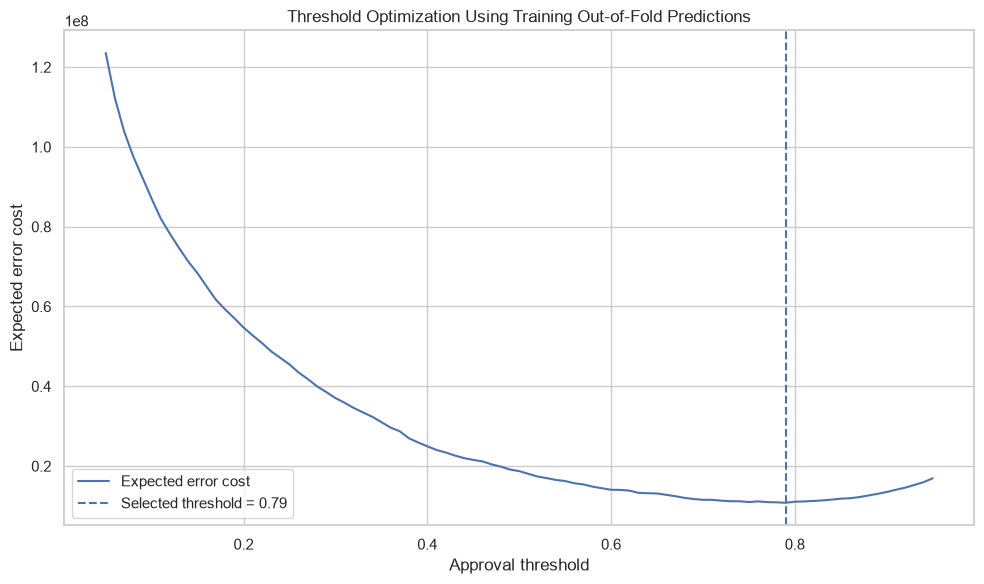

In [106]:
# Visualisation of threshold/business-cost trade-off
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(
    threshold_df["Threshold"],
    threshold_df["Expected_Cost"],
    label="Expected error cost"
)
ax1.axvline(best_threshold, linestyle="--", label=f"Selected threshold = {best_threshold:.2f}")
ax1.set_xlabel("Approval threshold")
ax1.set_ylabel("Expected error cost")
ax1.set_title("Threshold Optimization Using Training Out-of-Fold Predictions")
ax1.legend()

plt.tight_layout()
plt.show()

## Evaluation and Conclusion
8. Conduct thorough evaluation of final model:
- Assess models test data performance using your defined metrics
- Analyze performance across different data segments
- Identify potential biases or limitations
- Visualize model performance
    - Classification: Confusion Matrix/ROC-AUC
    - Regression: Scatter Plot (Predicted vs. Actual values)

9. Extract and interpret feature importance/significance:
- Which features had the most impact on your model?
- Does this lead to any potential business recommendations?

10. Prepare your final deliverable:
- Technical notebook with complete analysis
- Executive summary for business stakeholders
- Recommendations for implementation
- Documentation of potential improvements